# Experiment 1.3.10 — Fixed250+Linear vs stacked-bin SNN ablation

This notebook is **analysis-only**. SNN training and the paired Fixed250+Linear baseline are produced by the repository Slurm scripts.

Primary baseline: `[256,30] -> 16 fixed 250 ms bins -> per-channel count -> [16,30] -> flatten 480D -> train-only StandardScaler -> LogisticRegression(lbfgs)`, matching Experiment 1.3.4.

Stacked SNN input: `[256,30] -> [16 bins,16 within-bin steps,30] -> [16,480]`. All SNN conditions use whole-output-spike-count inference.

SNN factorial design: **5 architectures** (`1h128`, `1h256`, `1h512`, `1h1024`, `2h128`) × 2 objectives × 2 dynamics regimes × 3 user-disjoint split seeds = **60 SNN runs**, plus 3 paired Fixed250+Linear runs.

In [16]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_repo_root(start=None):
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'snn').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate writingRing repository root')

REPO_ROOT = find_repo_root()
EXPERIMENT_ID = 'experiment_1_3_10_stacked_bin_snn_ablation'
PROTOCOL_VERSION = 'stacked250_v1'
LABELS = tuple(sorted(('A','B','C','D','E','X','G','H','I','J','K','L')))
LABEL_TAG = 'labels_' + '-'.join(LABELS)
RESULTS_DIR = REPO_ROOT / 'notebooks' / 'artifacts' / EXPERIMENT_ID / PROTOCOL_VERSION / LABEL_TAG
RUNS_DIR = RESULTS_DIR / 'runs'
HISTORIES_DIR = RESULTS_DIR / 'histories'
BASELINE_DIR = RESULTS_DIR / 'baselines'
FIGURES_DIR = RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_SEEDS = (11,23,101)
ARCHITECTURES = ('1h128','1h256','1h512','1h1024','2h128')
OBJECTIVES = ('whole_count_ce','timestep_ce')
TRAIN_REGIMES = ('weight_only','trainable_dynamics')
EXPECTED_RUNS = 60
EXPECTED_BASELINES = 3
print('Results:', RESULTS_DIR)

Results: /home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_1_3_10_stacked_bin_snn_ablation/stacked250_v1/labels_A-B-C-D-E-G-H-I-J-K-L-X


## Load SNN and Fixed250+Linear artifacts; verify pairing

In [17]:
def flatten_run(p):
    row = {
        'run_key': p['run_key'], 'split_seed': int(p['split_seed']),
        'architecture': p['architecture'], 'objective': p['objective'],
        'train_regime': p['train_regime'], 'best_epoch': int(p['best_epoch']),
        'model_seed': int(p['model_seed']), 'sample_hash': p['sample_hash'],
        'trainable_parameters': int(p['parameter_counts']['trainable']),
        'history_file': p['history_file'],
    }
    for split in ('train','val','test'):
        m = p['metrics'][split]
        for key in ('loss','balanced_accuracy','accuracy','macro_f1','output_firing_rate'):
            row[f'{split}_{key}'] = float(m[key])
        for i, fr in enumerate(m.get('hidden_firing_rates', []), 1):
            row[f'{split}_hidden{i}_firing_rate'] = float(fr)
    for hidden in p['best_dynamics']['hidden']:
        layer = hidden['layer']
        for q in ('tau_syn_ms','tau_mem_ms','threshold'):
            row[f'{layer}_{q}_mean'] = float(hidden[q]['mean'])
            row[f'{layer}_{q}_std'] = float(hidden[q]['std'])
    return row

def flatten_baseline(p):
    row = {'baseline_id': p['baseline_id'], 'split_seed': int(p['split_seed']), 'sample_hash': p['sample_hash']}
    for split in ('train','val','test'):
        m = p['metrics'][split]
        for key in ('balanced_accuracy','accuracy','macro_f1'):
            row[f'{split}_{key}'] = float(m[key])
    return row

run_files = sorted(RUNS_DIR.glob('run_*.json')) if RUNS_DIR.exists() else []
payloads = [json.loads(p.read_text()) for p in run_files]
runs = pd.DataFrame(flatten_run(p) for p in payloads)
if not runs.empty:
    runs = runs.sort_values(['split_seed','architecture','train_regime','objective']).reset_index(drop=True)
baseline_files = sorted(BASELINE_DIR.glob('fixed250_count_linear_split*.json')) if BASELINE_DIR.exists() else []
baseline_payloads = [json.loads(p.read_text()) for p in baseline_files]
baseline = pd.DataFrame(flatten_baseline(p) for p in baseline_payloads)
if not baseline.empty:
    baseline = baseline.sort_values('split_seed').reset_index(drop=True)
print(f'SNN completed: {len(runs)}/{EXPECTED_RUNS}')
print(f'Fixed250+Linear completed: {len(baseline)}/{EXPECTED_BASELINES}')
display(runs.head())
display(baseline)
if not runs.empty:
    assert (runs.groupby('split_seed').sample_hash.nunique() == 1).all(), 'SNN split pairing failed'
    assert (runs.groupby(['split_seed','architecture']).model_seed.nunique() == 1).all(), 'Initialization pairing failed'
if len(baseline) == EXPECTED_BASELINES and not runs.empty:
    snn_hash = runs.groupby('split_seed', as_index=False).sample_hash.first().rename(columns={'sample_hash':'snn_sample_hash'})
    paired_hash = baseline.merge(snn_hash, on='split_seed', how='inner')
    assert len(paired_hash) == EXPECTED_BASELINES
    assert (paired_hash.sample_hash == paired_hash.snn_sample_hash).all(), 'Baseline/SNN sample pairing failed'

SNN completed: 60/60
Fixed250+Linear completed: 3/3


,run_key,split_seed,architecture,objective,train_regime,best_epoch,model_seed,sample_hash,trainable_parameters,history_file,...,hidden_1_threshold_std,train_hidden2_firing_rate,val_hidden2_firing_rate,test_hidden2_firing_rate,hidden_2_tau_syn_ms_mean,hidden_2_tau_syn_ms_std,hidden_2_tau_mem_ms_mean,hidden_2_tau_mem_ms_std,hidden_2_threshold_mean,hidden_2_threshold_std
0,split11__1h1024__timestep_ce__trainable_dynamics,11,1h1024,timestep_ce,trainable_dynamics,26,4247567133,fd3786ff7fca359f06912c9a8ffb3cb84f82534fdade3b...,506883,notebooks/artifacts/experiment_1_3_10_stacked_...,...,0.033018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,split11__1h1024__whole_count_ce__trainable_dyn...,11,1h1024,whole_count_ce,trainable_dynamics,22,4247567133,fd3786ff7fca359f06912c9a8ffb3cb84f82534fdade3b...,506883,notebooks/artifacts/experiment_1_3_10_stacked_...,...,0.020525,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,split11__1h1024__timestep_ce__weight_only,11,1h1024,timestep_ce,weight_only,51,4247567133,fd3786ff7fca359f06912c9a8ffb3cb84f82534fdade3b...,503808,notebooks/artifacts/experiment_1_3_10_stacked_...,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,split11__1h1024__whole_count_ce__weight_only,11,1h1024,whole_count_ce,weight_only,133,4247567133,fd3786ff7fca359f06912c9a8ffb3cb84f82534fdade3b...,503808,notebooks/artifacts/experiment_1_3_10_stacked_...,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,split11__1h128__timestep_ce__trainable_dynamics,11,1h128,timestep_ce,trainable_dynamics,57,2715002774,fd3786ff7fca359f06912c9a8ffb3cb84f82534fdade3b...,63363,notebooks/artifacts/experiment_1_3_10_stacked_...,...,0.043516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,baseline_id,split_seed,sample_hash,train_balanced_accuracy,train_accuracy,train_macro_f1,val_balanced_accuracy,val_accuracy,val_macro_f1,test_balanced_accuracy,test_accuracy,test_macro_f1
0,fixed250_count_linear,11,fd3786ff7fca359f06912c9a8ffb3cb84f82534fdade3b...,1.0,1.0,1.0,0.451709,0.458333,0.446482,0.683184,0.687500,0.682091
1,fixed250_count_linear,23,85d14b124241660c22126d21cff9471c44f1adeea642df...,1.0,1.0,1.0,0.618938,0.618785,0.602306,0.537563,0.553672,0.546811
2,fixed250_count_linear,101,904364bb02dc65c5d226b35e9acf226599682e62533d02...,1.0,1.0,1.0,0.652158,0.653846,0.651571,0.659180,0.641509,0.635094


## Aggregate performance across user splits

In [18]:
if runs.empty:
    summary = pd.DataFrame()
else:
    summary = (runs.groupby(['architecture','train_regime','objective'], as_index=False)
        .agg(n_splits=('split_seed','nunique'),
             mean_val_ba=('val_balanced_accuracy','mean'), sd_val_ba=('val_balanced_accuracy','std'),
             mean_test_ba=('test_balanced_accuracy','mean'), sd_test_ba=('test_balanced_accuracy','std'),
             mean_test_accuracy=('test_accuracy','mean'), sd_test_accuracy=('test_accuracy','std'),
             mean_test_macro_f1=('test_macro_f1','mean'), sd_test_macro_f1=('test_macro_f1','std'),
             mean_best_epoch=('best_epoch','mean')))
if baseline.empty:
    baseline_summary = pd.DataFrame()
else:
    baseline_summary = pd.DataFrame([{
        'method':'Fixed250 + Linear', 'n_splits':baseline.split_seed.nunique(),
        'mean_val_ba':baseline.val_balanced_accuracy.mean(), 'sd_val_ba':baseline.val_balanced_accuracy.std(),
        'mean_test_ba':baseline.test_balanced_accuracy.mean(), 'sd_test_ba':baseline.test_balanced_accuracy.std(),
        'mean_test_accuracy':baseline.test_accuracy.mean(), 'sd_test_accuracy':baseline.test_accuracy.std(),
        'mean_test_macro_f1':baseline.test_macro_f1.mean(), 'sd_test_macro_f1':baseline.test_macro_f1.std(),
    }])
display(baseline_summary)
display(summary)
if not summary.empty: summary.to_csv(RESULTS_DIR/'notebook_summary.csv',index=False)
if not baseline_summary.empty: baseline_summary.to_csv(RESULTS_DIR/'notebook_fixed250_linear_summary.csv',index=False)

,method,n_splits,mean_val_ba,sd_val_ba,mean_test_ba,sd_test_ba,mean_test_accuracy,sd_test_accuracy,mean_test_macro_f1,sd_test_macro_f1
0,Fixed250 + Linear,3,0.574268,0.107431,0.626642,0.078073,0.627561,0.067996,0.621332,0.068682


,architecture,train_regime,objective,n_splits,mean_val_ba,sd_val_ba,mean_test_ba,sd_test_ba,mean_test_accuracy,sd_test_accuracy,mean_test_macro_f1,sd_test_macro_f1,mean_best_epoch
0,1h1024,trainable_dynamics,timestep_ce,3,0.577855,0.088120,0.562749,0.062947,0.568576,0.061840,0.558199,0.070516,27.333333
1,1h1024,trainable_dynamics,whole_count_ce,3,0.543985,0.076154,0.574698,0.077421,0.577320,0.071007,0.570827,0.062938,22.000000
2,1h1024,weight_only,timestep_ce,3,0.594237,0.089130,0.601867,0.084113,0.609052,0.080747,0.602529,0.082610,71.000000
3,1h1024,weight_only,whole_count_ce,3,0.558942,0.062862,0.583549,0.090956,0.583852,0.091247,0.583233,0.087288,106.666667
4,1h128,trainable_dynamics,timestep_ce,3,0.523632,0.068262,0.524136,0.033026,0.528192,0.034317,0.524999,0.029972,48.333333
5,1h128,trainable_dynamics,whole_count_ce,3,0.570666,0.071344,0.538173,0.048712,0.543816,0.049950,0.537714,0.043932,99.000000
6,1h128,weight_only,timestep_ce,3,0.596313,0.117986,0.581773,0.067373,0.583866,0.064984,0.581662,0.064234,135.333333
7,1h128,weight_only,whole_count_ce,3,0.562770,0.095398,0.563312,0.068146,0.567613,0.063437,0.564585,0.062578,178.666667
8,1h256,trainable_dynamics,timestep_ce,3,0.568428,0.089771,0.559374,0.066160,0.571592,0.060437,0.559427,0.065801,30.666667
9,1h256,trainable_dynamics,whole_count_ce,3,0.558146,0.089441,0.557470,0.075295,0.558666,0.076427,0.552555,0.072944,128.666667


## Train objective loss vs epoch

,epoch,architecture,objective,train_regime,mean_train_objective_loss,sd_train_objective_loss,n_splits
0,1,1h1024,timestep_ce,trainable_dynamics,2.484913,9.738817e-06,3
1,1,1h1024,timestep_ce,weight_only,2.484913,9.738817e-06,3
2,1,1h1024,whole_count_ce,trainable_dynamics,2.484997,1.560824e-04,3
3,1,1h1024,whole_count_ce,weight_only,2.484997,1.560824e-04,3
4,1,1h128,timestep_ce,trainable_dynamics,2.484907,2.247274e-08,3


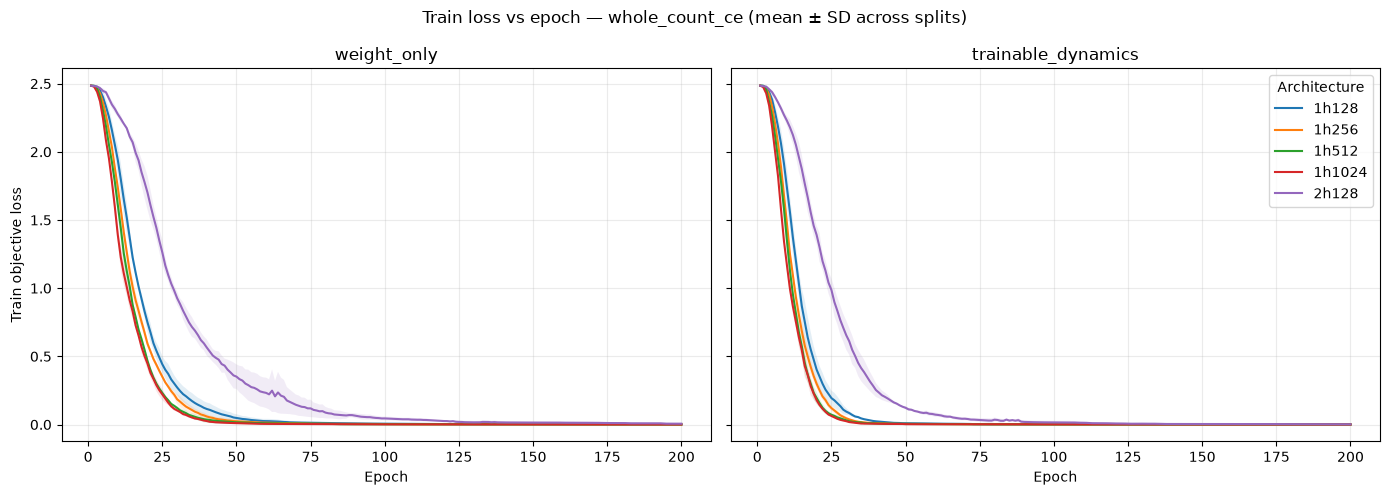

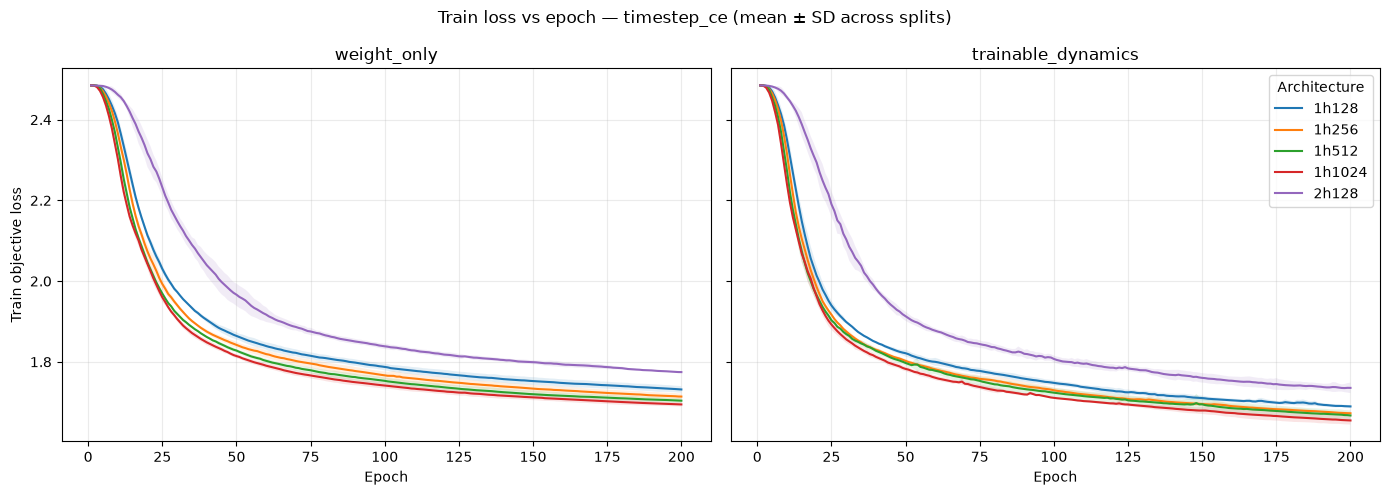

In [19]:
history_rows=[]
for p in payloads:
    history_path = REPO_ROOT / p['history_file']
    if not history_path.exists():
        continue
    h = pd.read_csv(history_path)
    h['split_seed'] = int(p['split_seed'])
    h['architecture'] = p['architecture']
    h['objective'] = p['objective']
    h['train_regime'] = p['train_regime']
    history_rows.append(h)
histories = pd.concat(history_rows, ignore_index=True) if history_rows else pd.DataFrame()
if not histories.empty:
    loss_summary=(histories.groupby(['epoch','architecture','objective','train_regime'],as_index=False)
        .agg(mean_train_objective_loss=('train_objective_loss','mean'),
             sd_train_objective_loss=('train_objective_loss','std'),
             n_splits=('split_seed','nunique')))
    display(loss_summary.head())
    loss_summary.to_csv(RESULTS_DIR/'train_loss_by_epoch_summary.csv',index=False)
    for objective in OBJECTIVES:
        fig, axes = plt.subplots(1,2,figsize=(14,5),sharey=True)
        for ax, regime in zip(axes, TRAIN_REGIMES):
            for architecture in ARCHITECTURES:
                part=loss_summary[(loss_summary.objective==objective)&(loss_summary.train_regime==regime)&(loss_summary.architecture==architecture)].sort_values('epoch')
                if part.empty: continue
                ax.plot(part.epoch,part.mean_train_objective_loss,label=architecture)
                lo=part.mean_train_objective_loss-part.sd_train_objective_loss.fillna(0)
                hi=part.mean_train_objective_loss+part.sd_train_objective_loss.fillna(0)
                ax.fill_between(part.epoch,lo,hi,alpha=.12)
            ax.set_title(regime); ax.set_xlabel('Epoch'); ax.grid(alpha=.25)
        axes[0].set_ylabel('Train objective loss')
        axes[1].legend(title='Architecture')
        fig.suptitle(f'Train loss vs epoch — {objective} (mean ± SD across splits)')
        fig.tight_layout()
        fig.savefig(FIGURES_DIR/f'train_loss_{objective}.png',dpi=180,bbox_inches='tight')
        plt.show()

## Main comparison: Fixed250+Linear vs SNN architecture × objective

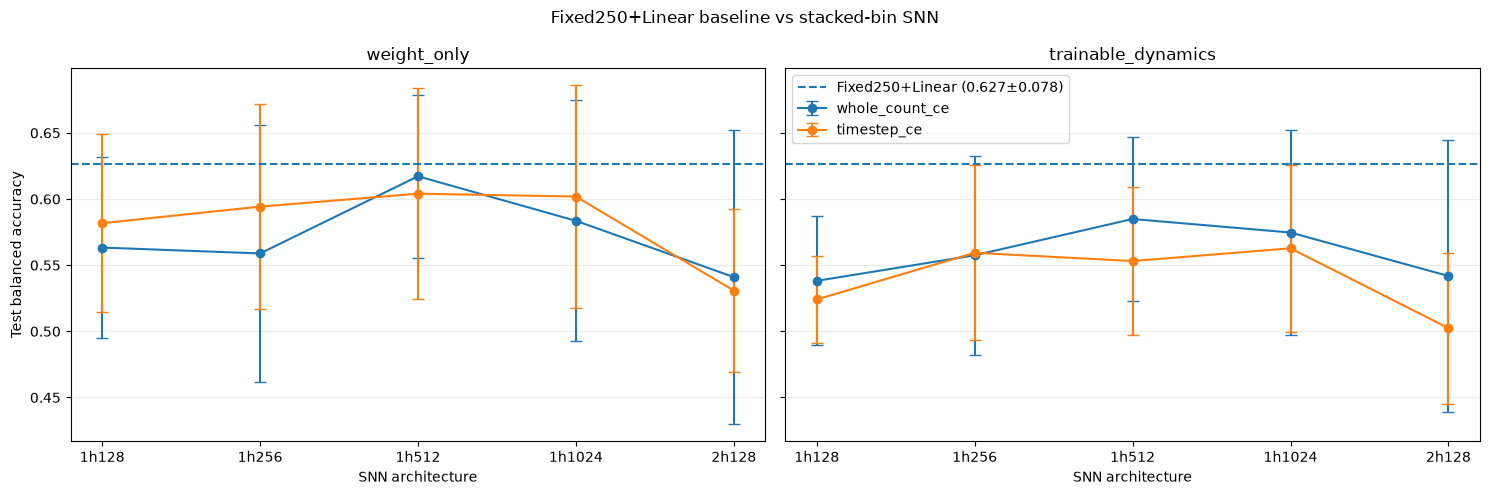

In [20]:
if not summary.empty:
    x=np.arange(len(ARCHITECTURES))
    fig,axes=plt.subplots(1,2,figsize=(15,5),sharey=True)
    baseline_mean=baseline.test_balanced_accuracy.mean() if not baseline.empty else np.nan
    baseline_sd=baseline.test_balanced_accuracy.std() if not baseline.empty else np.nan
    for ax,regime in zip(axes,TRAIN_REGIMES):
        for objective in OBJECTIVES:
            part=summary[(summary.train_regime==regime)&(summary.objective==objective)].set_index('architecture').reindex(ARCHITECTURES)
            ax.errorbar(x,part.mean_test_ba,yerr=part.sd_test_ba.fillna(0),marker='o',capsize=4,label=objective)
        if np.isfinite(baseline_mean):
            ax.axhline(baseline_mean,linestyle='--',linewidth=1.5,label=f'Fixed250+Linear ({baseline_mean:.3f}±{baseline_sd:.3f})')
        ax.set_xticks(x,ARCHITECTURES); ax.set_xlabel('SNN architecture'); ax.set_title(regime); ax.grid(axis='y',alpha=.25)
    axes[0].set_ylabel('Test balanced accuracy'); axes[1].legend()
    fig.suptitle('Fixed250+Linear baseline vs stacked-bin SNN'); fig.tight_layout()
    fig.savefig(FIGURES_DIR/'test_ba_snn_vs_fixed250_linear.png',dpi=180,bbox_inches='tight')
    plt.show()

## Paired SNN gain over Fixed250+Linear

In [21]:
if not runs.empty and len(baseline)==EXPECTED_BASELINES:
    paired=runs.merge(baseline[['split_seed','test_balanced_accuracy']].rename(columns={'test_balanced_accuracy':'baseline_test_ba'}),on='split_seed',how='inner')
    paired['delta_vs_fixed250_linear']=paired.test_balanced_accuracy-paired.baseline_test_ba
    paired_summary=(paired.groupby(['architecture','train_regime','objective'],as_index=False)
        .agg(mean_delta_ba=('delta_vs_fixed250_linear','mean'),sd_delta_ba=('delta_vs_fixed250_linear','std'),
             mean_snn_test_ba=('test_balanced_accuracy','mean'),mean_baseline_test_ba=('baseline_test_ba','mean')))
    display(paired_summary.sort_values('mean_delta_ba',ascending=False))
    paired.to_csv(RESULTS_DIR/'paired_snn_vs_fixed250_linear.csv',index=False)
    paired_summary.to_csv(RESULTS_DIR/'paired_snn_vs_fixed250_linear_summary.csv',index=False)

,architecture,train_regime,objective,mean_delta_ba,sd_delta_ba,mean_snn_test_ba,mean_baseline_test_ba
15,1h512,weight_only,whole_count_ce,-0.009441,0.049453,0.617201,0.626642
14,1h512,weight_only,timestep_ce,-0.022598,0.056315,0.604044,0.626642
2,1h1024,weight_only,timestep_ce,-0.024776,0.027863,0.601867,0.626642
10,1h256,weight_only,timestep_ce,-0.032380,0.032579,0.594262,0.626642
13,1h512,trainable_dynamics,whole_count_ce,-0.041727,0.028476,0.584915,0.626642
3,1h1024,weight_only,whole_count_ce,-0.043093,0.036439,0.583549,0.626642
6,1h128,weight_only,timestep_ce,-0.044870,0.026314,0.581773,0.626642
1,1h1024,trainable_dynamics,whole_count_ce,-0.051944,0.008489,0.574698,0.626642
7,1h128,weight_only,whole_count_ce,-0.063331,0.026810,0.563312,0.626642
0,1h1024,trainable_dynamics,timestep_ce,-0.063894,0.044111,0.562749,0.626642


## Paired effects inside the SNN

In [22]:
if not runs.empty:
    dyn=runs.pivot_table(index=['split_seed','architecture','objective'],columns='train_regime',values='test_balanced_accuracy',aggfunc='first').reset_index()
    if {'weight_only','trainable_dynamics'}.issubset(dyn.columns):
        dyn=dyn.dropna(subset=['weight_only','trainable_dynamics']).copy(); dyn['delta_ba']=dyn.trainable_dynamics-dyn.weight_only
        dyn_summary=dyn.groupby(['architecture','objective'],as_index=False).agg(mean_delta=('delta_ba','mean'),sd_delta=('delta_ba','std'))
        display(dyn_summary); dyn.to_csv(RESULTS_DIR/'paired_dynamics_deltas.csv',index=False)
    obj=runs.pivot_table(index=['split_seed','architecture','train_regime'],columns='objective',values='test_balanced_accuracy',aggfunc='first').reset_index()
    if {'whole_count_ce','timestep_ce'}.issubset(obj.columns):
        obj=obj.dropna(subset=['whole_count_ce','timestep_ce']).copy(); obj['delta_ba']=obj.whole_count_ce-obj.timestep_ce
        obj_summary=obj.groupby(['architecture','train_regime'],as_index=False).agg(mean_delta=('delta_ba','mean'),sd_delta=('delta_ba','std'))
        display(obj_summary); obj.to_csv(RESULTS_DIR/'paired_objective_deltas.csv',index=False)

,architecture,objective,mean_delta,sd_delta
0,1h1024,timestep_ce,-0.039118,0.028488
1,1h1024,whole_count_ce,-0.008851,0.028382
2,1h128,timestep_ce,-0.057637,0.038778
3,1h128,whole_count_ce,-0.025139,0.023546
4,1h256,timestep_ce,-0.034888,0.012890
5,1h256,whole_count_ce,-0.001402,0.022614
6,1h512,timestep_ce,-0.050909,0.027212
7,1h512,whole_count_ce,-0.032286,0.021275
8,2h128,timestep_ce,-0.028408,0.042833
9,2h128,whole_count_ce,0.000823,0.025128


,architecture,train_regime,mean_delta,sd_delta
0,1h1024,trainable_dynamics,0.011950,0.036899
1,1h1024,weight_only,-0.018317,0.009185
2,1h128,trainable_dynamics,0.014037,0.016694
3,1h128,weight_only,-0.018461,0.001032
4,1h256,trainable_dynamics,-0.001905,0.018296
5,1h256,weight_only,-0.035391,0.026676
6,1h512,trainable_dynamics,0.031780,0.034742
7,1h512,weight_only,0.013157,0.018746
8,2h128,trainable_dynamics,0.039405,0.090097
9,2h128,weight_only,0.010175,0.050322


## Learned hidden-neuron dynamics

In [23]:
rows=[]
for p in payloads:
    if p['train_regime']!='trainable_dynamics': continue
    for h in p['best_dynamics']['hidden']:
        rows.append({'split_seed':p['split_seed'],'architecture':p['architecture'],'objective':p['objective'],'layer':h['layer'],
                     'tau_syn_ms':h['tau_syn_ms']['mean'],'tau_mem_ms':h['tau_mem_ms']['mean'],'threshold':h['threshold']['mean']})
learned=pd.DataFrame(rows)
if not learned.empty:
    learned_summary=(learned.groupby(['architecture','objective','layer'],as_index=False)
        .agg(mean_tau_syn_ms=('tau_syn_ms','mean'),sd_tau_syn_ms=('tau_syn_ms','std'),
             mean_tau_mem_ms=('tau_mem_ms','mean'),sd_tau_mem_ms=('tau_mem_ms','std'),
             mean_threshold=('threshold','mean'),sd_threshold=('threshold','std')))
    display(learned_summary); learned_summary.to_csv(RESULTS_DIR/'learned_dynamics_summary.csv',index=False)
if not runs.empty: runs.to_csv(RESULTS_DIR/'notebook_all_runs.csv',index=False)
if not baseline.empty: baseline.to_csv(RESULTS_DIR/'notebook_fixed250_linear_runs.csv',index=False)

,architecture,objective,layer,mean_tau_syn_ms,sd_tau_syn_ms,mean_tau_mem_ms,sd_tau_mem_ms,mean_threshold,sd_threshold
0,1h1024,timestep_ce,hidden_1,5.702484e+05,193015.909640,25.131796,0.223666,0.493677,0.001139
1,1h1024,whole_count_ce,hidden_1,1.334195e+05,109601.932686,24.016961,0.120505,0.490539,0.000177
2,1h128,timestep_ce,hidden_1,2.035084e+06,70612.083985,27.395173,0.198169,0.458117,0.006741
3,1h128,whole_count_ce,hidden_1,1.261859e+06,186300.781162,26.056699,0.357572,0.470993,0.001292
4,1h256,timestep_ce,hidden_1,1.078826e+06,428508.418678,26.096189,0.579093,0.475031,0.002314
5,1h256,whole_count_ce,hidden_1,1.017883e+06,474396.693085,25.517897,0.606244,0.479191,0.002072
6,1h512,timestep_ce,hidden_1,9.466998e+05,554971.188733,25.648534,0.588869,0.482884,0.000771
7,1h512,whole_count_ce,hidden_1,7.125394e+05,288378.995970,24.789826,0.485361,0.484593,0.001415
8,2h128,timestep_ce,hidden_1,1.790665e+06,563801.477865,26.682074,0.496244,0.454753,0.011050
9,2h128,timestep_ce,hidden_2,6.925964e+05,187272.346554,24.759371,0.397017,0.487409,0.006835
